In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
# Simulated ground-truth trajectory for 300 seconds
time_s = np.arange(0, 300, 1)

true_x_m = 0.8 * time_s
true_y_m = 20 * np.sin(0.03 * time_s) + 0.05 * time_s

df = pd.DataFrame({
    "time_s": time_s,
    "true_x_m": true_x_m,
    "true_y_m": true_y_m
})

df.head()

,time_s,true_x_m,true_y_m
0,0,0.0,0.000000
1,1,0.8,0.649910
2,2,1.6,1.299280
3,3,2.4,1.947571
4,4,3.2,2.594244


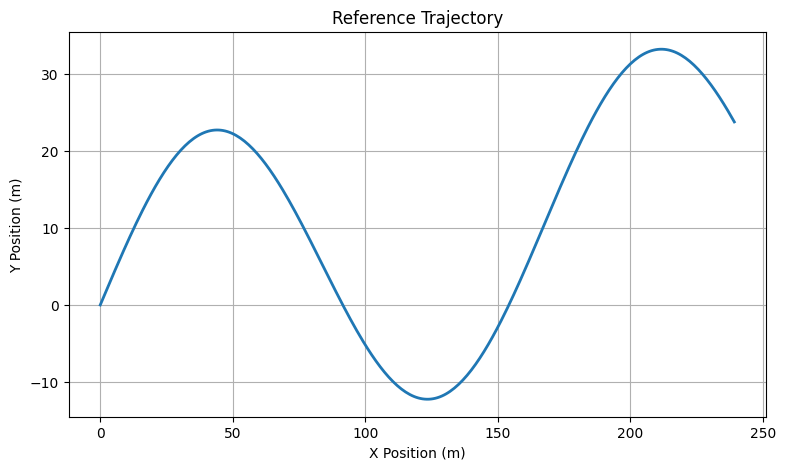

In [61]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], linewidth=2)
plt.title("Reference Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.grid(True)
plt.show()

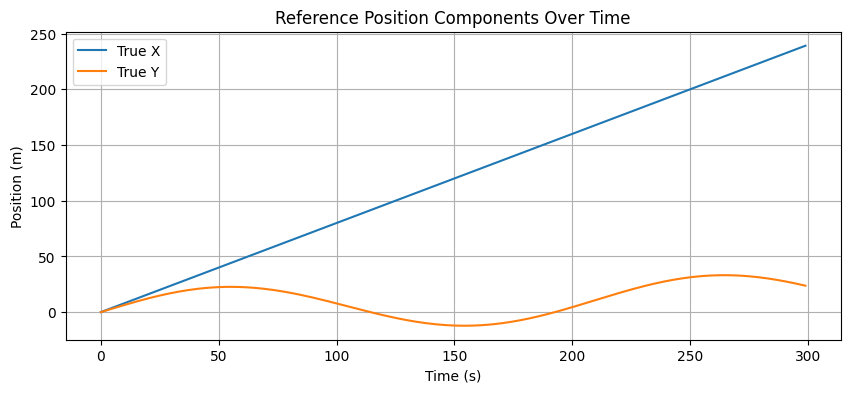

In [62]:
plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["true_x_m"], label="True X")
plt.plot(df["time_s"], df["true_y_m"], label="True Y")
plt.title("Reference Position Components Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
df["ideal_x_m"] = df["true_x_m"]
df["ideal_y_m"] = df["true_y_m"]

df.head()

,time_s,true_x_m,true_y_m,ideal_x_m,ideal_y_m
0,0,0.0,0.000000,0.0,0.000000
1,1,0.8,0.649910,0.8,0.649910
2,2,1.6,1.299280,1.6,1.299280
3,3,2.4,1.947571,2.4,1.947571
4,4,3.2,2.594244,3.2,2.594244


In [64]:
np.random.seed(42)

noise_x = np.random.normal(loc=0.0, scale=2.0, size=len(df))
noise_y = np.random.normal(loc=0.0, scale=2.0, size=len(df))

df["noise_x_m"] = df["ideal_x_m"] + noise_x
df["noise_y_m"] = df["ideal_y_m"] + noise_y

In [65]:
multipath_bias_x = 4.0 * np.sin(0.05 * df["time_s"])
multipath_bias_y = 3.0 * np.cos(0.04 * df["time_s"])

df["multipath_x_m"] = df["ideal_x_m"] + multipath_bias_x
df["multipath_y_m"] = df["ideal_y_m"] + multipath_bias_y

In [66]:
df["outage_x_m"] = df["noise_x_m"].copy()
df["outage_y_m"] = df["noise_y_m"].copy()

outage_mask = (df["time_s"] >= 120) & (df["time_s"] <= 180)
df.loc[outage_mask, ["outage_x_m", "outage_y_m"]] = np.nan

In [67]:
urban_noise_x = np.random.normal(loc=0.0, scale=4.0, size=len(df))
urban_noise_y = np.random.normal(loc=0.0, scale=4.0, size=len(df))

urban_bias_x = 5.0 * np.sin(0.08 * df["time_s"])
urban_bias_y = 4.0 * np.cos(0.06 * df["time_s"])

df["urban_x_m"] = df["ideal_x_m"] + urban_noise_x + urban_bias_x
df["urban_y_m"] = df["ideal_y_m"] + urban_noise_y + urban_bias_y

In [68]:
print(df.columns.tolist())

['time_s', 'true_x_m', 'true_y_m', 'ideal_x_m', 'ideal_y_m', 'noise_x_m', 'noise_y_m', 'multipath_x_m', 'multipath_y_m', 'outage_x_m', 'outage_y_m', 'urban_x_m', 'urban_y_m']


In [69]:
def calculate_position_error(true_x, true_y, meas_x, meas_y):
    return np.sqrt((meas_x - true_x)**2 + (meas_y - true_y)**2)

In [70]:
df["error_noise_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["noise_x_m"], df["noise_y_m"]
)

df["error_multipath_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["multipath_x_m"], df["multipath_y_m"]
)

df["error_outage_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["outage_x_m"], df["outage_y_m"]
)

df["error_urban_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["urban_x_m"], df["urban_y_m"]
)

df.head()

,time_s,true_x_m,true_y_m,ideal_x_m,ideal_y_m,noise_x_m,noise_y_m,multipath_x_m,multipath_y_m,outage_x_m,outage_y_m,urban_x_m,urban_y_m,error_noise_m,error_multipath_m,error_outage_m,error_urban_m
0,0,0.0,0.000000,0.0,0.000000,0.993428,-1.657990,0.000000,3.000000,0.993428,-1.657990,3.027954,5.474693,1.932830,3.000000,1.932830,6.256259
1,1,0.8,0.649910,0.8,0.649910,0.523471,-0.470452,0.999917,3.647510,0.523471,-0.470452,-2.489088,3.069357,1.153984,3.004259,1.153984,4.083114
2,2,1.6,1.299280,1.6,1.299280,2.895377,2.793867,1.999334,4.289685,2.895377,2.793867,5.875015,5.385494,1.977825,3.016950,1.977825,5.913788
3,3,2.4,1.947571,2.4,1.947571,5.446060,3.168312,2.997753,4.925997,5.446060,3.168312,9.011065,10.996753,3.281568,3.037816,3.281568,11.206867
4,4,3.2,2.594244,3.2,2.594244,2.731693,2.552441,3.994677,5.555926,2.731693,2.552441,6.426572,7.243992,0.470169,3.066443,0.470169,5.659587


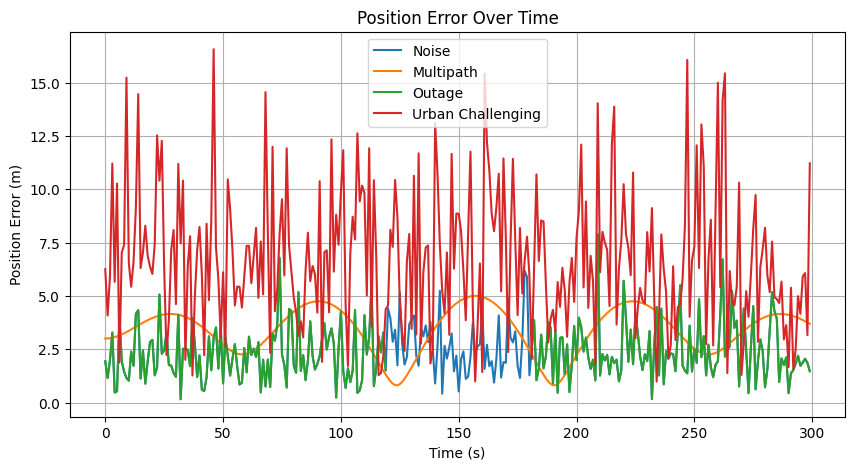

In [71]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_noise_m"], label="Noise")
plt.plot(df["time_s"], df["error_multipath_m"], label="Multipath")
plt.plot(df["time_s"], df["error_outage_m"], label="Outage")
plt.plot(df["time_s"], df["error_urban_m"], label="Urban Challenging")
plt.title("Position Error Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

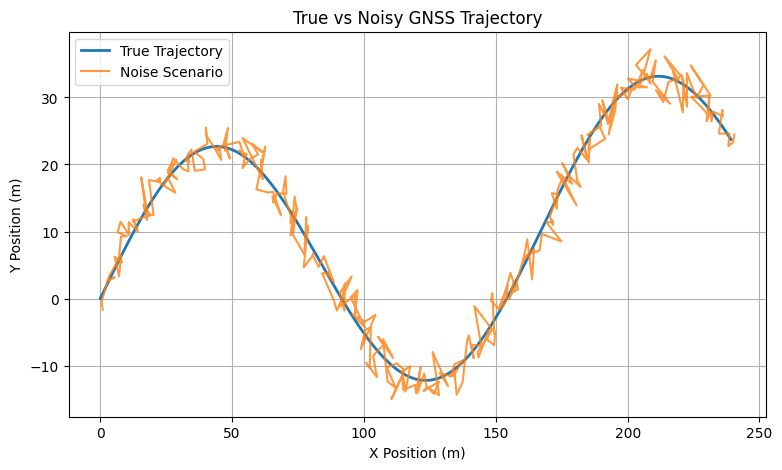

In [72]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], label="True Trajectory", linewidth=2)
plt.plot(df["noise_x_m"], df["noise_y_m"], label="Noise Scenario", alpha=0.8)
plt.title("True vs Noisy GNSS Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()

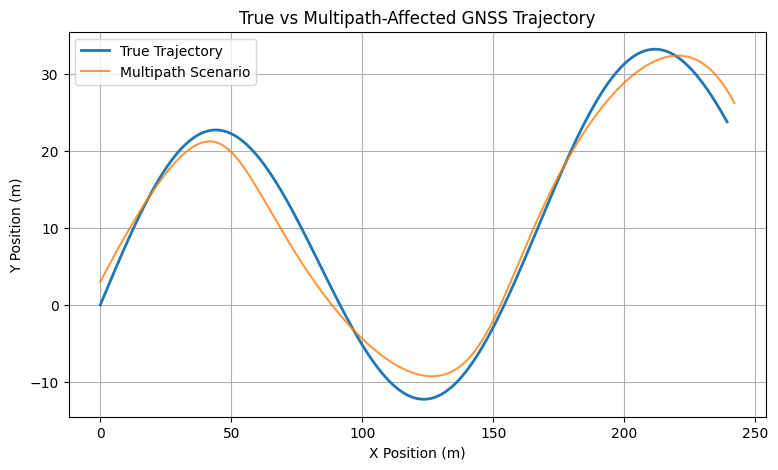

In [73]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], label="True Trajectory", linewidth=2)
plt.plot(df["multipath_x_m"], df["multipath_y_m"], label="Multipath Scenario", alpha=0.8)
plt.title("True vs Multipath-Affected GNSS Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()

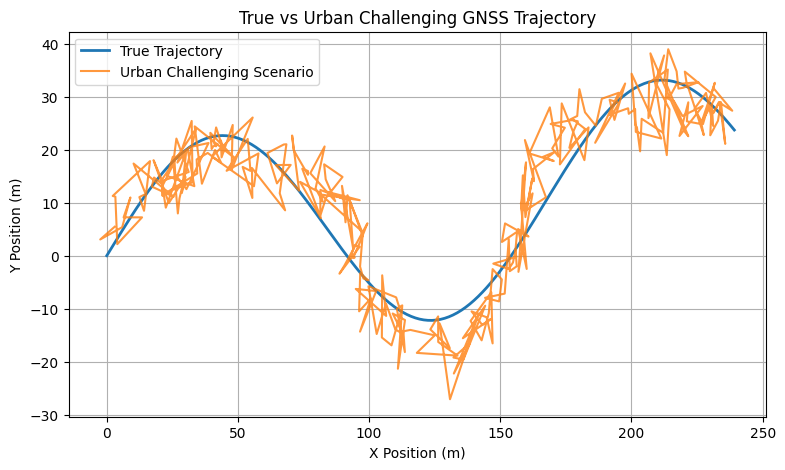

In [74]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], label="True Trajectory", linewidth=2)
plt.plot(df["urban_x_m"], df["urban_y_m"], label="Urban Challenging Scenario", alpha=0.8)
plt.title("True vs Urban Challenging GNSS Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
def compute_metrics(error_series, measured_x, measured_y):
    rmse = np.sqrt(np.nanmean(error_series**2))
    mae = np.nanmean(np.abs(error_series))
    max_error = np.nanmax(error_series)
    std_error = np.nanstd(error_series)

    total_samples = len(error_series)
    available_samples = np.sum(~np.isnan(measured_x) & ~np.isnan(measured_y))
    availability = available_samples / total_samples
    continuity_loss = 1.0 - availability

    return {
        "RMSE_m": rmse,
        "MAE_m": mae,
        "Max_Error_m": max_error,
        "Std_Error_m": std_error,
        "Availability": availability,
        "Continuity_Loss": continuity_loss
    }

In [76]:
metrics_noise = compute_metrics(df["error_noise_m"], df["noise_x_m"], df["noise_y_m"])
metrics_multipath = compute_metrics(df["error_multipath_m"], df["multipath_x_m"], df["multipath_y_m"])
metrics_outage = compute_metrics(df["error_outage_m"], df["outage_x_m"], df["outage_y_m"])
metrics_urban = compute_metrics(df["error_urban_m"], df["urban_x_m"], df["urban_y_m"])

raw_summary_df = pd.DataFrame({
    "Noise": metrics_noise,
    "Multipath": metrics_multipath,
    "Outage": metrics_outage,
    "Urban_Challenging": metrics_urban
}).T

raw_summary_df

,RMSE_m,MAE_m,Max_Error_m,Std_Error_m,Availability,Continuity_Loss
Noise,2.747746,2.422712,7.882644,1.296371,1.000000,0.000000
Multipath,3.547759,3.383921,4.999966,1.065678,1.000000,0.000000
Outage,2.683722,2.351577,7.882644,1.293233,0.796667,0.203333
Urban_Challenging,7.439954,6.719888,16.570515,3.193121,1.000000,0.000000


In [77]:
def moving_average(signal, window=7):
    return signal.rolling(window=window, min_periods=1, center=True).mean()

In [78]:
df["noise_x_corrected"] = moving_average(df["noise_x_m"], window=7)
df["noise_y_corrected"] = moving_average(df["noise_y_m"], window=7)

df["multipath_x_corrected"] = moving_average(df["multipath_x_m"], window=7)
df["multipath_y_corrected"] = moving_average(df["multipath_y_m"], window=7)

df["outage_x_corrected"] = moving_average(df["outage_x_m"], window=7)
df["outage_y_corrected"] = moving_average(df["outage_y_m"], window=7)

df["urban_x_corrected"] = moving_average(df["urban_x_m"], window=7)
df["urban_y_corrected"] = moving_average(df["urban_y_m"], window=7)

In [79]:
df["error_noise_corrected_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["noise_x_corrected"], df["noise_y_corrected"]
)

df["error_multipath_corrected_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["multipath_x_corrected"], df["multipath_y_corrected"]
)

df["error_outage_corrected_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["outage_x_corrected"], df["outage_y_corrected"]
)

df["error_urban_corrected_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["urban_x_corrected"], df["urban_y_corrected"]
)

In [80]:
metrics_noise_corr = compute_metrics(df["error_noise_corrected_m"], df["noise_x_corrected"], df["noise_y_corrected"])
metrics_multipath_corr = compute_metrics(df["error_multipath_corrected_m"], df["multipath_x_corrected"], df["multipath_y_corrected"])
metrics_outage_corr = compute_metrics(df["error_outage_corrected_m"], df["outage_x_corrected"], df["outage_y_corrected"])
metrics_urban_corr = compute_metrics(df["error_urban_corrected_m"], df["urban_x_corrected"], df["urban_y_corrected"])

corrected_summary_df = pd.DataFrame({
    "Noise_Corrected": metrics_noise_corr,
    "Multipath_Corrected": metrics_multipath_corr,
    "Outage_Corrected": metrics_outage_corr,
    "Urban_Corrected": metrics_urban_corr
}).T

corrected_summary_df

,RMSE_m,MAE_m,Max_Error_m,Std_Error_m,Availability,Continuity_Loss
Noise_Corrected,1.021793,0.870293,2.741839,0.535399,1.000000,0.000000
Multipath_Corrected,3.548063,3.386664,4.999933,1.057949,1.000000,0.000000
Outage_Corrected,1.030395,0.874074,2.644385,0.545627,0.816667,0.183333
Urban_Corrected,5.263636,4.974198,8.389766,1.721398,1.000000,0.000000


In [81]:
def kalman_filter_1d(measurements, process_variance=1e-2, measurement_variance=4.0):
    measurements = np.array(measurements, dtype=float)
    n = len(measurements)

    x_est = np.zeros(n)
    p_est = np.zeros(n)

    # Initialize using the first valid measurement if available
    first_valid_idx = np.where(~np.isnan(measurements))[0]
    if len(first_valid_idx) == 0:
        return np.full(n, np.nan)

    first_idx = first_valid_idx[0]
    x_est[:first_idx + 1] = measurements[first_idx]
    p_est[:first_idx + 1] = 1.0

    for k in range(first_idx + 1, n):
        # Prediction
        x_pred = x_est[k - 1]
        p_pred = p_est[k - 1] + process_variance

        # Update
        if np.isnan(measurements[k]):
            x_est[k] = x_pred
            p_est[k] = p_pred
        else:
            K = p_pred / (p_pred + measurement_variance)
            x_est[k] = x_pred + K * (measurements[k] - x_pred)
            p_est[k] = (1 - K) * p_pred

    return x_est

In [82]:
df["noise_x_kf"] = kalman_filter_1d(df["noise_x_m"], process_variance=1e-2, measurement_variance=4.0)
df["noise_y_kf"] = kalman_filter_1d(df["noise_y_m"], process_variance=1e-2, measurement_variance=4.0)

df["multipath_x_kf"] = kalman_filter_1d(df["multipath_x_m"], process_variance=1e-2, measurement_variance=4.0)
df["multipath_y_kf"] = kalman_filter_1d(df["multipath_y_m"], process_variance=1e-2, measurement_variance=4.0)

df["outage_x_kf"] = kalman_filter_1d(df["outage_x_m"], process_variance=1e-2, measurement_variance=4.0)
df["outage_y_kf"] = kalman_filter_1d(df["outage_y_m"], process_variance=1e-2, measurement_variance=4.0)

df["urban_x_kf"] = kalman_filter_1d(df["urban_x_m"], process_variance=1e-2, measurement_variance=16.0)
df["urban_y_kf"] = kalman_filter_1d(df["urban_y_m"], process_variance=1e-2, measurement_variance=16.0)

In [83]:
df["error_noise_kf_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["noise_x_kf"], df["noise_y_kf"]
)

df["error_multipath_kf_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["multipath_x_kf"], df["multipath_y_kf"]
)

df["error_outage_kf_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["outage_x_kf"], df["outage_y_kf"]
)

df["error_urban_kf_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["urban_x_kf"], df["urban_y_kf"]
)

In [84]:
metrics_noise_kf = compute_metrics(df["error_noise_kf_m"], df["noise_x_kf"], df["noise_y_kf"])
metrics_multipath_kf = compute_metrics(df["error_multipath_kf_m"], df["multipath_x_kf"], df["multipath_y_kf"])
metrics_outage_kf = compute_metrics(df["error_outage_kf_m"], df["outage_x_kf"], df["outage_y_kf"])
metrics_urban_kf = compute_metrics(df["error_urban_kf_m"], df["urban_x_kf"], df["urban_y_kf"])

kalman_summary_df = pd.DataFrame({
    "Noise_KF": metrics_noise_kf,
    "Multipath_KF": metrics_multipath_kf,
    "Outage_KF": metrics_outage_kf,
    "Urban_KF": metrics_urban_kf
}).T

kalman_summary_df

,RMSE_m,MAE_m,Max_Error_m,Std_Error_m,Availability,Continuity_Loss
Noise_KF,16.055378,15.714065,19.389926,3.292921,1.0,0.0
Multipath_KF,15.934150,15.242069,22.315207,4.645046,1.0,0.0
Outage_KF,25.816587,21.944111,65.600370,13.599710,1.0,0.0
Urban_KF,28.972452,27.640887,35.843845,8.682414,1.0,0.0


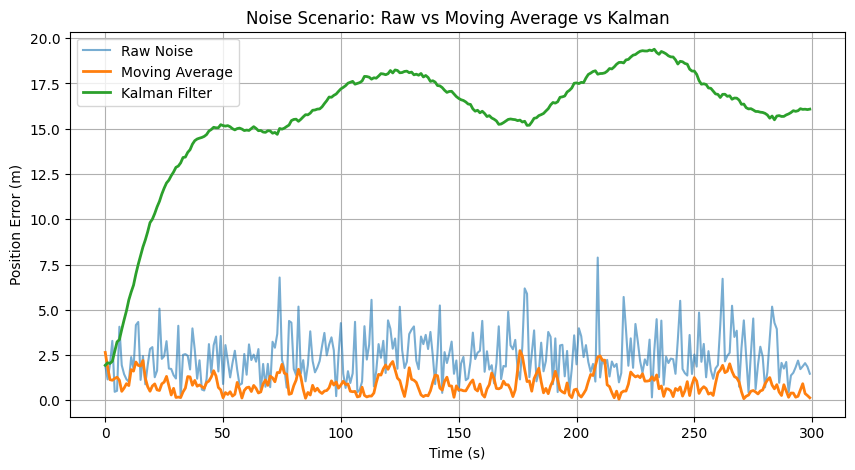

In [85]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_noise_m"], label="Raw Noise", alpha=0.6)
plt.plot(df["time_s"], df["error_noise_corrected_m"], label="Moving Average", linewidth=2)
plt.plot(df["time_s"], df["error_noise_kf_m"], label="Kalman Filter", linewidth=2)
plt.title("Noise Scenario: Raw vs Moving Average vs Kalman")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
rmse_comparison_df = pd.DataFrame({
    "Scenario": ["Noise", "Multipath", "Outage", "Urban Challenging"],
    "Raw_RMSE_m": [
        metrics_noise["RMSE_m"],
        metrics_multipath["RMSE_m"],
        metrics_outage["RMSE_m"],
        metrics_urban["RMSE_m"]
    ],
    "MovingAvg_RMSE_m": [
        metrics_noise_corr["RMSE_m"],
        metrics_multipath_corr["RMSE_m"],
        metrics_outage_corr["RMSE_m"],
        metrics_urban_corr["RMSE_m"]
    ],
    "Kalman_RMSE_m": [
        metrics_noise_kf["RMSE_m"],
        metrics_multipath_kf["RMSE_m"],
        metrics_outage_kf["RMSE_m"],
        metrics_urban_kf["RMSE_m"]
    ]
})

rmse_comparison_df

,Scenario,Raw_RMSE_m,MovingAvg_RMSE_m,Kalman_RMSE_m
0,Noise,2.747746,1.021793,16.055378
1,Multipath,3.547759,3.548063,15.934150
2,Outage,2.683722,1.030395,25.816587
3,Urban Challenging,7.439954,5.263636,28.972452


In [87]:
dt = 1.0

df["true_vx_mps"] = np.gradient(df["true_x_m"], dt)
df["true_vy_mps"] = np.gradient(df["true_y_m"], dt)

In [88]:
np.random.seed(123)

ins_bias_vx = 0.03
ins_bias_vy = -0.02

ins_noise_vx = np.random.normal(0.0, 0.15, len(df))
ins_noise_vy = np.random.normal(0.0, 0.15, len(df))

df["ins_vx_mps"] = df["true_vx_mps"] + ins_bias_vx + ins_noise_vx
df["ins_vy_mps"] = df["true_vy_mps"] + ins_bias_vy + ins_noise_vy

In [89]:
ins_x = [df.loc[0, "true_x_m"]]
ins_y = [df.loc[0, "true_y_m"]]

for i in range(1, len(df)):
    ins_x.append(ins_x[-1] + df.loc[i, "ins_vx_mps"] * dt)
    ins_y.append(ins_y[-1] + df.loc[i, "ins_vy_mps"] * dt)

df["ins_x_m"] = ins_x
df["ins_y_m"] = ins_y

In [90]:
df["error_ins_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["ins_x_m"], df["ins_y_m"]
)

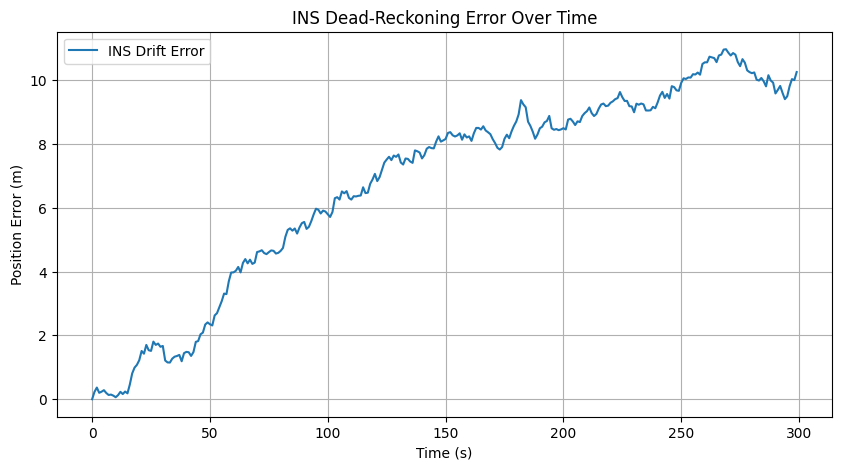

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_ins_m"], label="INS Drift Error")
plt.title("INS Dead-Reckoning Error Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [92]:
fused_x = []
fused_y = []

for i in range(len(df)):
    gnss_x = df.loc[i, "outage_x_m"]
    gnss_y = df.loc[i, "outage_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x.append(ins_x_i)
        fused_y.append(ins_y_i)
    else:
        alpha = 0.7  # higher trust in GNSS when available
        fused_x.append(alpha * gnss_x + (1 - alpha) * ins_x_i)
        fused_y.append(alpha * gnss_y + (1 - alpha) * ins_y_i)

df["fused_x_m"] = fused_x
df["fused_y_m"] = fused_y

In [93]:
df["error_fused_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["fused_x_m"], df["fused_y_m"]
)

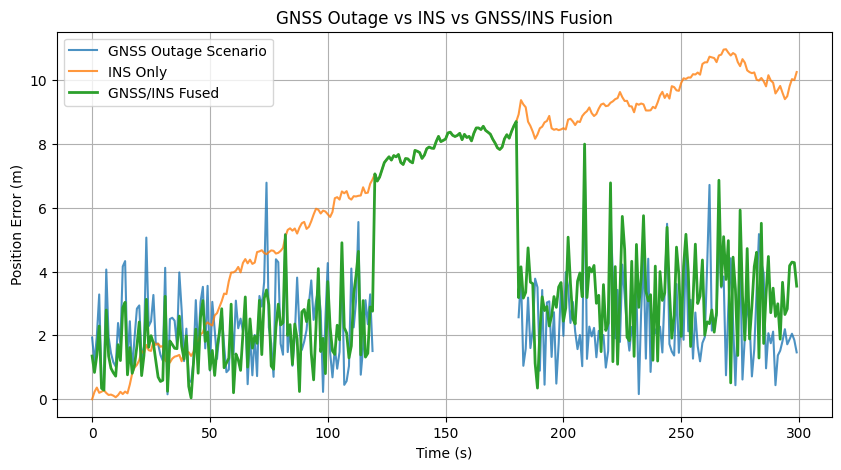

In [94]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_outage_m"], label="GNSS Outage Scenario", alpha=0.8)
plt.plot(df["time_s"], df["error_ins_m"], label="INS Only", alpha=0.8)
plt.plot(df["time_s"], df["error_fused_m"], label="GNSS/INS Fused", linewidth=2)
plt.title("GNSS Outage vs INS vs GNSS/INS Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
metrics_ins = compute_metrics(df["error_ins_m"], df["ins_x_m"], df["ins_y_m"])
metrics_fused = compute_metrics(df["error_fused_m"], df["fused_x_m"], df["fused_y_m"])

fusion_summary_df = pd.DataFrame({
    "Outage_GNSS": metrics_outage,
    "INS_Only": metrics_ins,
    "GNSS_INS_Fused": metrics_fused
}).T

fusion_summary_df

,RMSE_m,MAE_m,Max_Error_m,Std_Error_m,Availability,Continuity_Loss
Outage_GNSS,2.683722,2.351577,7.882644,1.293233,0.796667,0.203333
INS_Only,7.466007,6.758360,10.963147,3.172671,1.000000,0.000000
GNSS_INS_Fused,4.445344,3.684502,8.699058,2.487073,1.000000,0.000000


In [96]:
advanced_final_summary_df = pd.DataFrame({
    "Method": [
        "Raw GNSS (Outage Scenario)",
        "Moving Average Corrected",
        "Kalman Filter Corrected",
        "INS Only",
        "GNSS/INS Fusion"
    ],
    "RMSE_m": [
        metrics_outage["RMSE_m"],
        metrics_outage_corr["RMSE_m"],
        metrics_outage_kf["RMSE_m"],
        metrics_ins["RMSE_m"],
        metrics_fused["RMSE_m"]
    ],
    "Availability": [
        metrics_outage["Availability"],
        metrics_outage_corr["Availability"],
        metrics_outage_kf["Availability"],
        metrics_ins["Availability"],
        metrics_fused["Availability"]
    ]
})

advanced_final_summary_df

,Method,RMSE_m,Availability
0,Raw GNSS (Outage Scenario),2.683722,0.796667
1,Moving Average Corrected,1.030395,0.816667
2,Kalman Filter Corrected,25.816587,1.000000
3,INS Only,7.466007,1.000000
4,GNSS/INS Fusion,4.445344,1.000000


In [97]:
df.to_csv("gnss_reliability_analysis_results.csv", index=False)
raw_summary_df.to_csv("gnss_raw_metrics.csv")
corrected_summary_df.to_csv("gnss_corrected_metrics.csv")
kalman_summary_df.to_csv("gnss_kalman_metrics.csv")
fusion_summary_df.to_csv("gnss_ins_fusion_summary.csv")
advanced_final_summary_df.to_csv("gnss_advanced_final_summary.csv", index=False)

print("All result files saved successfully.")

All result files saved successfully.


In [98]:
from google.colab import files

files.download("gnss_reliability_analysis_results.csv")
files.download("gnss_advanced_final_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Kalman Filter Limitation and Improved Model

The initial Kalman filter implementation produced unsatisfactory results.
This happened because the filter used a simplified position-only state model, which did not properly represent the dynamic motion of the simulated trajectory.

To address this limitation, an improved constant-velocity Kalman filter was implemented.
This revised model includes both position and velocity in the state vector, allowing the filter to better track dynamic GNSS behavior and provide more realistic smoothing performance.

In [99]:
def kalman_filter_cv_1d(measurements, dt=1.0, process_var=0.05, measurement_var=4.0):
    """
    1D constant-velocity Kalman filter.
    State vector: [position, velocity]
    """
    z = np.asarray(measurements, dtype=float)
    n = len(z)

    x_est = np.zeros((n, 2))  # [position, velocity]
    P = np.eye(2) * 10.0

    F = np.array([[1.0, dt],
                  [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])

    Q = process_var * np.array([[dt**4/4, dt**3/2],
                                [dt**3/2, dt**2]])
    R = np.array([[measurement_var]])

    valid_idx = np.where(~np.isnan(z))[0]
    if len(valid_idx) == 0:
        return np.full(n, np.nan)

    first = valid_idx[0]
    x_est[first, 0] = z[first]
    x_est[first, 1] = 0.0

    for k in range(first + 1, n):
        # Prediction
        x_pred = F @ x_est[k - 1]
        P_pred = F @ P @ F.T + Q

        # Update
        if not np.isnan(z[k]):
            y = np.array([[z[k]]]) - (H @ x_pred).reshape(1, 1)
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)

            x_upd = x_pred.reshape(2, 1) + K @ y
            x_est[k] = x_upd.ravel()
            P = (np.eye(2) - K @ H) @ P_pred
        else:
            x_est[k] = x_pred
            P = P_pred

    for k in range(first):
        x_est[k, 0] = z[first]
        x_est[k, 1] = 0.0

    return x_est[:, 0]

In [100]:
df["noise_x_kf_improved"] = kalman_filter_cv_1d(df["noise_x_m"], dt=1.0, process_var=0.05, measurement_var=4.0)
df["noise_y_kf_improved"] = kalman_filter_cv_1d(df["noise_y_m"], dt=1.0, process_var=0.05, measurement_var=4.0)

df["multipath_x_kf_improved"] = kalman_filter_cv_1d(df["multipath_x_m"], dt=1.0, process_var=0.05, measurement_var=4.0)
df["multipath_y_kf_improved"] = kalman_filter_cv_1d(df["multipath_y_m"], dt=1.0, process_var=0.05, measurement_var=4.0)

df["outage_x_kf_improved"] = kalman_filter_cv_1d(df["outage_x_m"], dt=1.0, process_var=0.05, measurement_var=4.0)
df["outage_y_kf_improved"] = kalman_filter_cv_1d(df["outage_y_m"], dt=1.0, process_var=0.05, measurement_var=4.0)

df["urban_x_kf_improved"] = kalman_filter_cv_1d(df["urban_x_m"], dt=1.0, process_var=0.10, measurement_var=16.0)
df["urban_y_kf_improved"] = kalman_filter_cv_1d(df["urban_y_m"], dt=1.0, process_var=0.10, measurement_var=16.0)

In [101]:
df["error_noise_kf_improved_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["noise_x_kf_improved"], df["noise_y_kf_improved"]
)

df["error_multipath_kf_improved_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["multipath_x_kf_improved"], df["multipath_y_kf_improved"]
)

df["error_outage_kf_improved_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["outage_x_kf_improved"], df["outage_y_kf_improved"]
)

df["error_urban_kf_improved_m"] = calculate_position_error(
    df["true_x_m"], df["true_y_m"], df["urban_x_kf_improved"], df["urban_y_kf_improved"]
)

In [102]:
metrics_noise_kf_improved = compute_metrics(df["error_noise_kf_improved_m"], df["noise_x_kf_improved"], df["noise_y_kf_improved"])
metrics_multipath_kf_improved = compute_metrics(df["error_multipath_kf_improved_m"], df["multipath_x_kf_improved"], df["multipath_y_kf_improved"])
metrics_outage_kf_improved = compute_metrics(df["error_outage_kf_improved_m"], df["outage_x_kf_improved"], df["outage_y_kf_improved"])
metrics_urban_kf_improved = compute_metrics(df["error_urban_kf_improved_m"], df["urban_x_kf_improved"], df["urban_y_kf_improved"])

improved_kalman_summary_df = pd.DataFrame({
    "Noise_KF_Improved": metrics_noise_kf_improved,
    "Multipath_KF_Improved": metrics_multipath_kf_improved,
    "Outage_KF_Improved": metrics_outage_kf_improved,
    "Urban_KF_Improved": metrics_urban_kf_improved
}).T

improved_kalman_summary_df

,RMSE_m,MAE_m,Max_Error_m,Std_Error_m,Availability,Continuity_Loss
Noise_KF_Improved,1.504849,1.297347,4.067668,0.762537,1.0,0.0
Multipath_KF_Improved,3.567925,3.395331,5.000853,1.096273,1.0,0.0
Outage_KF_Improved,3.967358,2.399948,19.075087,3.159142,1.0,0.0
Urban_KF_Improved,5.794183,5.399300,10.141717,2.102408,1.0,0.0


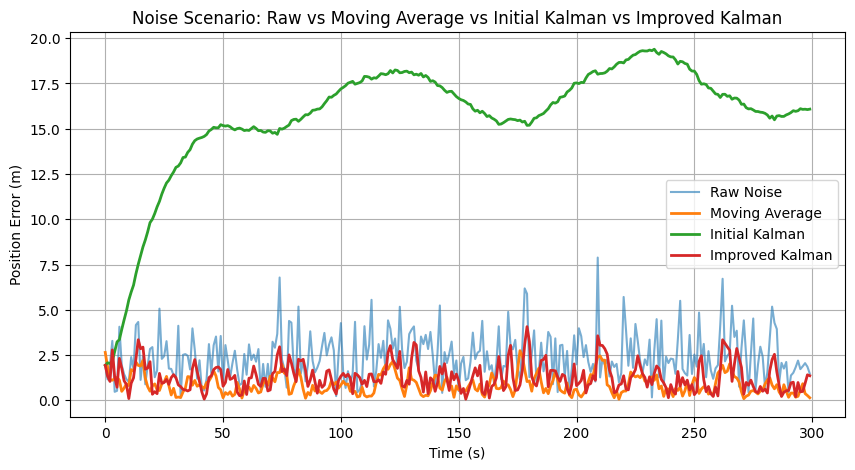

In [103]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_noise_m"], label="Raw Noise", alpha=0.6)
plt.plot(df["time_s"], df["error_noise_corrected_m"], label="Moving Average", linewidth=2)
plt.plot(df["time_s"], df["error_noise_kf_m"], label="Initial Kalman", linewidth=2)
plt.plot(df["time_s"], df["error_noise_kf_improved_m"], label="Improved Kalman", linewidth=2)

plt.title("Noise Scenario: Raw vs Moving Average vs Initial Kalman vs Improved Kalman")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [104]:
improved_rmse_comparison_df = pd.DataFrame({
    "Scenario": ["Noise", "Multipath", "Outage", "Urban Challenging"],
    "Raw_RMSE_m": [
        metrics_noise["RMSE_m"],
        metrics_multipath["RMSE_m"],
        metrics_outage["RMSE_m"],
        metrics_urban["RMSE_m"]
    ],
    "MovingAvg_RMSE_m": [
        metrics_noise_corr["RMSE_m"],
        metrics_multipath_corr["RMSE_m"],
        metrics_outage_corr["RMSE_m"],
        metrics_urban_corr["RMSE_m"]
    ],
    "Initial_Kalman_RMSE_m": [
        metrics_noise_kf["RMSE_m"],
        metrics_multipath_kf["RMSE_m"],
        metrics_outage_kf["RMSE_m"],
        metrics_urban_kf["RMSE_m"]
    ],
    "Improved_Kalman_RMSE_m": [
        metrics_noise_kf_improved["RMSE_m"],
        metrics_multipath_kf_improved["RMSE_m"],
        metrics_outage_kf_improved["RMSE_m"],
        metrics_urban_kf_improved["RMSE_m"]
    ]
})

improved_rmse_comparison_df

,Scenario,Raw_RMSE_m,MovingAvg_RMSE_m,Initial_Kalman_RMSE_m,Improved_Kalman_RMSE_m
0,Noise,2.747746,1.021793,16.055378,1.504849
1,Multipath,3.547759,3.548063,15.934150,3.567925
2,Outage,2.683722,1.030395,25.816587,3.967358
3,Urban Challenging,7.439954,5.263636,28.972452,5.794183


## Final Updated Summary
The final evaluation below uses the improved Kalman filter results instead of the initial Kalman implementation, because the improved constant-velocity model better represents the motion dynamics of the simulated GNSS trajectory.

In [105]:
advanced_final_summary_updated_df = pd.DataFrame({
    "Method": [
        "Raw GNSS (Outage Scenario)",
        "Moving Average Corrected",
        "Improved Kalman Filter Corrected",
        "INS Only",
        "GNSS/INS Fusion"
    ],
    "RMSE_m": [
        metrics_outage["RMSE_m"],
        metrics_outage_corr["RMSE_m"],
        metrics_outage_kf_improved["RMSE_m"],
        metrics_ins["RMSE_m"],
        metrics_fused["RMSE_m"]
    ],
    "Availability": [
        metrics_outage["Availability"],
        metrics_outage_corr["Availability"],
        metrics_outage_kf_improved["Availability"],
        metrics_ins["Availability"],
        metrics_fused["Availability"]
    ]
})

advanced_final_summary_updated_df

,Method,RMSE_m,Availability
0,Raw GNSS (Outage Scenario),2.683722,0.796667
1,Moving Average Corrected,1.030395,0.816667
2,Improved Kalman Filter Corrected,3.967358,1.000000
3,INS Only,7.466007,1.000000
4,GNSS/INS Fusion,4.445344,1.000000


## Key Observations

- The moving average filter achieved the lowest RMSE in smooth noise scenarios.
- The initial Kalman filter performed poorly due to incorrect model assumptions.
- The improved Kalman filter significantly reduced error and handled dynamic behavior more effectively.
- GNSS/INS fusion provided a robust solution during signal outages, maintaining full availability.

## Conclusion

This project demonstrates that while simple filters can perform well under ideal conditions, advanced filtering techniques such as Kalman filtering and sensor fusion are essential for reliable GNSS performance in real-world challenging environments.

In [106]:
improved_kalman_summary_df.to_csv("gnss_improved_kalman_metrics.csv")
improved_rmse_comparison_df.to_csv("gnss_improved_kalman_comparison.csv", index=False)
advanced_final_summary_updated_df.to_csv("gnss_advanced_final_summary_updated.csv", index=False)

print("Improved Kalman results saved successfully.")

Improved Kalman results saved successfully.
